In [1]:
# ===== IMPORT LIBRARIES =====
import os
import torch
import tqdm
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

from monai.data import DataLoader, CacheDataset
from monai.networks.nets import UNet
from monai.inferers import sliding_window_inference
from monai.utils import set_determinism
from monai.losses import DiceLoss, DiceCELoss
from monai.metrics import DiceMetric, ConfusionMatrixMetric
from monai.inferers import sliding_window_inference
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd, Orientationd,
    ScaleIntensityd, SpatialPadd, RandCropByPosNegLabeld,
    RandFlipd, RandRotate90d, RandAffined, RandBiasFieldd,
    RandGaussianNoised, RandAdjustContrastd,
    ToTensord, EnsureTyped, AsDiscreted
)
from monai.networks.utils import one_hot


In [2]:
# ======= CREATING DICTS =======
def get_data_list(root_dir):
    data_dicts = []
    for patient_id in os.listdir(root_dir):
        patient_path = os.path.join(root_dir, patient_id, "preRT")
        if not os.path.isdir(patient_path):
            print(f"⚠️ Le répertoire {patient_path} n'existe pas ou n'est pas un répertoire.")
            continue
        # Trouver fichiers T2 et masque
        t2_files = os.path.join(patient_path, f"{patient_id}_preRT_T2.nii.gz")
        mask_files = os.path.join(patient_path, f"{patient_id}_preRT_mask.nii.gz")

        if t2_files and mask_files:
            data_dicts.append({
                "image": t2_files,
                "label": mask_files
            })
        else:
            print(f"⚠️ Fichiers manquants pour le patient {patient_id}")
    return data_dicts

# Construction des jeux d'entraînement et de validation
train_data_dir = "/cluster/projects/vc/data/mic/open/HNTS-MRG/train"
test_data_dir = "/cluster/projects/vc/data/mic/open/HNTS-MRG/test"

print("Creating dicts")
# Obtenir les données d'entraînement complètes
train_data_full = get_data_list(train_data_dir)

# Diviser les données d'entraînement en train et validation
train_data, val_data = train_test_split(train_data_full, train_size=0.2, test_size=0.1)

# Obtenir les données de test
test_data = get_data_list(test_data_dir)

# Ensure the directory exists before saving the model
save_dir = os.path.expanduser("~/HNTS-MRG/results")
os.makedirs(save_dir, exist_ok=True)

Creating dicts


In [3]:
# ======= TRANSFORMING TRAINING DATAS =======

print("Transforming training datas")
# Transforms
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityd(keys=["image"]),
    SpatialPadd(keys=["image", "label"], spatial_size=(96, 96, 96)),

    # Crop positive and negative patches
    RandCropByPosNegLabeld(
        keys=["image", "label"], label_key="label",
        spatial_size=(96, 96, 96), pos=1, neg=1, num_samples=4,
        image_key="image", image_threshold=0
    ),

    # Spatial augmentations
    RandFlipd(keys=["image", "label"], spatial_axis=0, prob=0.5),
    RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
    RandAffined(
        keys=["image", "label"],
        prob=0.5,
        rotate_range=(0.1, 0.1, 0.1),
        shear_range=None,
        translate_range=(10, 10, 5),
        scale_range=(0.1, 0.1, 0.1),
        mode=("bilinear", "nearest")
    ),

    # Intensity augmentations
    RandBiasFieldd(keys=["image"], prob=0.3),
    RandGaussianNoised(keys=["image"], prob=0.2, mean=0.0, std=0.1),
    RandAdjustContrastd(keys=["image"], prob=0.3, gamma=(0.7, 1.5)),

    ToTensord(keys=["image", "label"]),
])
val_transforms = [
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityd(keys=["image"]),
    ToTensord(keys=["image", "label"]),
]

# Datasets and Loaders
train_ds = CacheDataset(data=train_data, transform=train_transforms, cache_rate=1.0)
train_loader = DataLoader(train_ds, batch_size=3, shuffle=True)

val_ds = CacheDataset(data=val_data, transform=val_transforms, cache_rate=1.0)
val_loader = DataLoader(val_ds, batch_size=1)

Transforming training datas


Loading dataset:   0%|          | 0/26 [00:00<?, ?it/s]

Loading dataset: 100%|██████████| 13/13 [00:30<00:00,  2.32s/it]


In [4]:
for val_data in val_loader:
    val_images, val_labels = val_data["image"].cuda(), val_data["label"].cuda()
    print(f"Validation images shape: {val_images.shape}")
    print(f"Validation labels shape: {val_labels.shape}")
    break
for train_data in train_loader:
    train_images, train_labels = train_data["image"].cuda(), train_data["label"].cuda()
    print(f"Train images shape: {train_images.shape}")
    print(f"Train labels shape: {train_labels.shape}")
    break
# Validation images shape: torch.Size([1, 1, 171, 171, 77])
# Validation labels shape: torch.Size([1, 1, 171, 171, 77])
# Train images shape: torch.Size([12, 1, 96, 96, 96])
# Train labels shape: torch.Size([12, 1, 96, 96, 96])

Validation images shape: torch.Size([1, 1, 171, 171, 80])
Validation labels shape: torch.Size([1, 1, 171, 171, 80])
Train images shape: torch.Size([12, 1, 96, 96, 96])
Train labels shape: torch.Size([12, 1, 96, 96, 96])


In [5]:
# ====== MODEL ======

# Check if CUDA is available and set the device accordingly
if torch.cuda.is_available():
    print("CUDA is available. Using GPU.")
    device = torch.device("cuda")
else:
    print("CUDA is not available. Using CPU.")
    device = torch.device("cpu")

# Define the model
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=3,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=6,
    dropout=0.3,
).to(device)

# ====== LOSS ======
# classic one
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
# loss_function = DiceLoss()

# Dice + CrossEntropy Loss
# This is a good choice if you have a multi-class segmentation problem and want to balance the contribution of each class.
# loss_function = DiceCELoss(to_onehot_y=True, softmax=True, include_background=False)
# loss_function = DiceCELoss(include_background=False)

# Adjust alpha (false negative penalty) and beta (false positive penalty) based on your task. This is particularly good if your tumor is very small in volume.
# loss_function = TverskyLoss(to_onehot_y=True, softmax=True, alpha=0.7, beta=0.3)

# ====== METRICS ======
dice_metric = DiceMetric(include_background=False, reduction="mean")

# ====== OPTIMIZER ======
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
max_epochs = 5

CUDA is available. Using GPU.


/cluster/home/vutourni/HNTS-MRG/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [ ]:
# ====== TRAINING ======
print("Training")
# Training loop

best_dice = 0.0
for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0

    tqdm_bar = tqdm.tqdm(train_loader, desc="Training", unit="batch")
    for batch_data in tqdm_bar:
        tqdm_bar.set_description(f"Epoch {epoch+1}/{max_epochs} - Training")
        tqdm_bar.set_postfix(loss=epoch_loss)
        tqdm_bar.refresh()
        
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        tqdm_bar.set_postfix(loss=epoch_loss / len(train_loader))
        tqdm_bar.refresh()

    print(f"Train loss: {epoch_loss / len(train_loader):.4f}")

    with torch.no_grad():
        dice_metric.reset()

        tqdm_bar = tqdm.tqdm(val_loader, desc="Validation", unit="batch")
        for val_data in tqdm_bar:
            tqdm_bar.set_description(f"Epoch {epoch+1}/{max_epochs} - Validation")
            tqdm_bar.refresh()

            val_inputs = val_data["image"].to(device)
            val_labels = val_data["label"].to(device)

            val_outputs = sliding_window_inference(val_inputs, (96, 96, 96), sw_batch_size=4, predictor=model)

            dice_metric(y_pred=val_outputs, y=val_labels)
            # confusion_metric(y_pred=val_outputs, y=val_labels)
            tqdm_bar.set_postfix(dice=dice_metric.aggregate().item())
            tqdm_bar.refresh()

        dice_score = dice_metric.aggregate().item()
        print(f"Validation Dice: {dice_score:.4f}")

        dice_metric.reset()

        # Save model
        torch.save(model.state_dict(), os.path.join(save_dir, "model_epoch_{}.pth".format(epoch)))
        # save best model
        if epoch == 0 or dice_score > best_dice:
            best_dice = dice_score
            torch.save(model.state_dict(), os.path.join(save_dir,"best_model.pth"))
            print(f"Best model saved with Dice: {best_dice:.4f}")
        else:
            print(f"Model not improved. Current best Dice: {best_dice:.4f}")

# Save the final model
torch.save(model.state_dict(), os.path.join(save_dir,"final_model.pth"))
print("Training completed.")

Training


Training:   0%|          | 0/9 [00:00<?, ?batch/s]

Epoch 1/5 - Training:  44%|████▍     | 4/9 [00:23<00:29,  5.92s/batch, loss=0.36]  


KeyboardInterrupt: 

In [3]:
# ======= LOADING TEST DATAS =======

test_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityd(keys=["image"]),
    ToTensord(keys=["image", "label"]),
    # AsDiscreted(keys="label")
])

test_ds = CacheDataset(data=test_data, transform=test_transforms, cache_rate=1.0)
test_loader = DataLoader(test_ds, batch_size=1)


Loading dataset: 100%|██████████| 20/20 [00:40<00:00,  2.01s/it]


In [6]:
# ====== LOADING MODEL ======
model_name = "model_epoch_199.pth"
model_path = os.path.join(save_dir, model_name)
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [29]:
# ====== METRICS ======
test_dice_metric = DiceMetric(include_background=True, reduction="mean")
metrics_list = [ "sensitivity", "specificity", "accuracy", "precision", "f1"]
confusion_metric = ConfusionMatrixMetric(include_background=True, reduction="mean", metric_name=metrics_list)


In [30]:
# ===== TESTING =====
print("Testing")
model.eval()

with torch.no_grad():
    test_dice_metric.reset()
    confusion_metric.reset()

    tqdm_bar = tqdm.tqdm(test_loader, desc="Testing", unit="batch")
    for test_data in tqdm_bar:
        tqdm_bar.set_description("Testing")
        tqdm_bar.refresh()

        test_inputs = test_data["image"].to(device)
        test_labels = test_data["label"].to(device)
        
        test_outputs = sliding_window_inference(test_inputs, (96, 96, 96), sw_batch_size=4, predictor=model)

        test_labels = one_hot(test_labels, num_classes=test_outputs.shape[1])

        test_dice_metric(y_pred=test_outputs, y=test_labels)
        confusion_metric(y_pred=test_outputs, y=test_labels)
        tqdm_bar.set_postfix(dice=test_dice_metric.aggregate().item())
        tqdm_bar.refresh()

    test_metric = test_dice_metric.aggregate().item()
    test_dice_metric.reset()

    cm_stats = confusion_metric.aggregate()

    # print(cm_stats)
    for name, value in zip(metrics_list, cm_stats):
        print(f"{name}: {value.item():.4f}")

    confusion_metric.reset()

    print(f"Test Dice: {test_metric:.4f}")

Testing


Testing: 100%|██████████| 20/20 [00:05<00:00,  3.46batch/s, dice=0.36]

sensitivity: 0.0000
specificity: 0.0000
accuracy: 0.0000
precision: 0.0000
f1: 0.0000
Test Dice: 0.3597


In [18]:
def plot_prediction(image, label, prediction, slice_index=None, title="", save_path=None):
    """
    Affiche ou sauvegarde une image d'une coupe axiale du volume.
    - image, label, prediction : np.array (3D)
    - slice_index : int ou None (si None => coupe centrale)
    - save_path : chemin de sauvegarde de l'image (si non None, ne montre pas)
    """
    if slice_index is None:
        slice_index = image.shape[2] // 2

    image_slice = image[:, :, slice_index]
    label_slice = label[:, :, slice_index]
    pred_slice = prediction[:, :, slice_index]

    plt.figure(figsize=(15, 5))
    plt.suptitle(title)

    plt.subplot(1, 3, 1)
    plt.imshow(image_slice, cmap="gray")
    plt.title("Image MRI")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(label_slice, cmap="viridis", interpolation="none")
    plt.title("Vérité Terrain")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_slice, cmap="viridis", interpolation="none")
    plt.title("Prédiction")
    plt.axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()


In [ ]:
# Convert tensors to numpy
image_np = test_inputs[0, 0].cpu().numpy()

label_np = test_labels[0].cpu().numpy()  # Assuming one-hot
        

output_np = test_outputs[0].cpu().detach().numpy()
pred_np = np.argmax(output_np, axis=0)

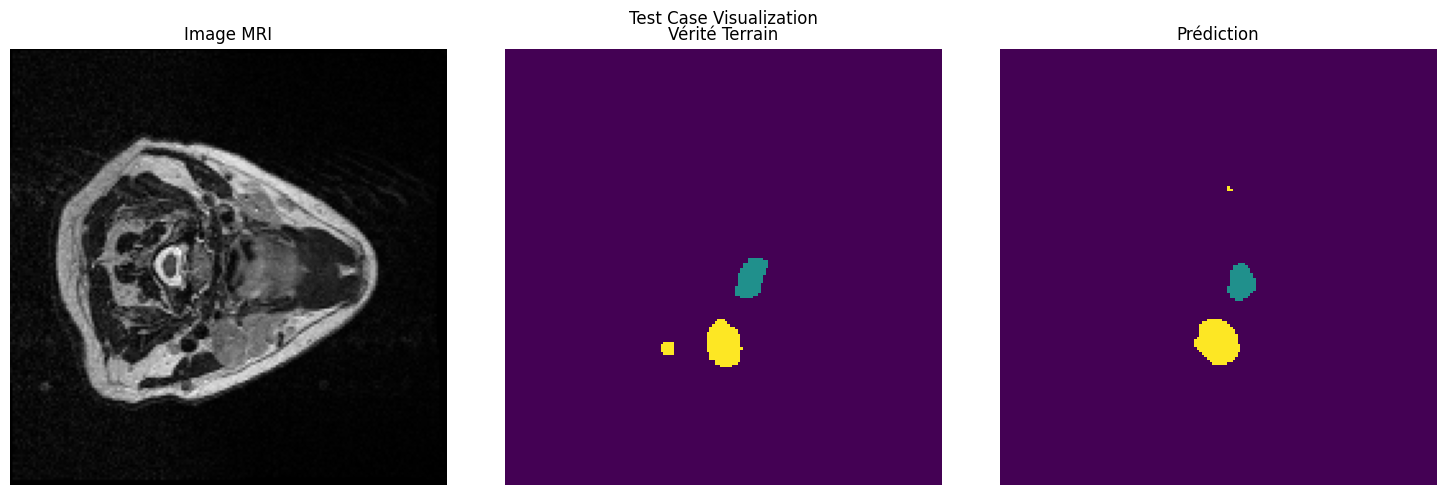

In [20]:
plot_prediction(image_np, label_np, pred_np, title=f"Test Case Visualization")


In [9]:
save_images_dir = os.path.join(save_dir, "test_images")
os.makedirs(save_images_dir, exist_ok=True)

In [27]:
model.eval()

for i, test_data in enumerate(test_loader):
    test_inputs = test_data["image"].to(device)
    test_labels = test_data["label"].to(device)
    test_labels = one_hot(test_labels, num_classes=test_outputs.shape[1])

    test_outputs = sliding_window_inference(test_inputs, (96, 96, 96), sw_batch_size=4, predictor=model)

    # Pour chaque image du batch
    tqdm_bar = tqdm.tqdm(range(test_inputs.shape[4]), desc="Creating images", unit="image")

    for j in range(test_inputs.shape[4]):
        tqdm_bar.set_description(f"Test {i+1}/{len(test_loader)} - Image {j+1}/{test_inputs.shape[4]}")
        tqdm_bar.refresh()
        # Pour chaque slice de l'image

        image_np = test_inputs[0, 0].cpu().numpy()
        label_np = test_labels[0].cpu().numpy()
        label_np = np.argmax(label_np, axis=0) if label_np.ndim == 4 else label_np

        output_np = test_outputs[0].cpu().detach().numpy()
        pred_np = np.argmax(output_np, axis=0)

        plot_prediction(
            image_np,
            label_np,
            pred_np,
            slice_index=j,
            title=f"Test Case #{i}_{j}",
            save_path=os.path.join(save_images_dir, f"test_vis_{i:03d}_{j}.png")
        )
        tqdm_bar.set_postfix(image=j)
        tqdm_bar.refresh()
    tqdm_bar.close()
print("Test images created.")

    

Test 1/20 - Image 1/1:   0%|          | 0/1 [00:00<?, ?image/s]

Test 4/20 - Image 9/1:   0%|          | 0/1 [00:04<?, ?image/s, image=7]

KeyboardInterrupt: 

In [28]:
import imageio
import os
import re
from collections import defaultdict

# Répertoire contenant les images
image_dir = os.path.expanduser("~/HNTS-MRG/results/test_images")
output_dir = os.path.join(save_dir, "gifs")
os.makedirs(output_dir, exist_ok=True)

# Regrouper les images par patient ID
patient_images = defaultdict(list)
pattern = r"test_vis_(\d+)_(\d+)\.png"

# Lister et classer les images
for filename in os.listdir(image_dir):
    match = re.match(pattern, filename)
    if match:
        patient_id = int(match.group(1))
        slice_idx = int(match.group(2))
        patient_images[patient_id].append((slice_idx, filename))

# Créer un GIF par patient
for patient_id, slices in patient_images.items():
    # Trier les slices par index
    sorted_slices = sorted(slices, key=lambda x: x[0])
    images = [imageio.imread(os.path.join(image_dir, f)) for _, f in sorted_slices]
    
    # Chemin de sauvegarde du GIF
    gif_path = os.path.join(output_dir, f"patient_{patient_id:03d}.gif")
    
    # Créer le GIF
    imageio.mimsave(gif_path, images, duration=0.5)
    print(f"✅ GIF sauvegardé : {gif_path}")


/tmp/ipykernel_2183582/443453811.py:27: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(os.path.join(image_dir, f)) for _, f in sorted_slices]


✅ GIF sauvegardé : /cluster/home/vutourni/HNTS-MRG/results/gifs/patient_002.gif
✅ GIF sauvegardé : /cluster/home/vutourni/HNTS-MRG/results/gifs/patient_001.gif
✅ GIF sauvegardé : /cluster/home/vutourni/HNTS-MRG/results/gifs/patient_004.gif
✅ GIF sauvegardé : /cluster/home/vutourni/HNTS-MRG/results/gifs/patient_000.gif
✅ GIF sauvegardé : /cluster/home/vutourni/HNTS-MRG/results/gifs/patient_003.gif
✅ GIF sauvegardé : /cluster/home/vutourni/HNTS-MRG/results/gifs/patient_005.gif
